In [1]:
%pip install scanpy
import scanpy as sc

print(sc.__version__)

Note: you may need to restart the kernel to use updated packages.
1.11.5


C:\Users\Ishika Gupta\AppData\Local\Temp\ipykernel_18076\2814701918.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [2]:
# scanpy is a Python library for analyzing single-cell gene expression data. It provides tools for preprocessing, visualization, and analysis of single-cell RNA sequencing (scRNA-seq) data. 
# With scanpy, researchers can perform tasks such as normalization, dimensionality reduction, clustering, and differential expression analysis to gain insights into cellular heterogeneity and identify different cell types based on their gene expression profiles.

In [3]:
# Load PBMC dataset
adata = sc.datasets.pbmc3k()

# this is a single-cell RNA sequencing dataset of peripheral blood mononuclear cells (PBMCs) from a healthy donor. The dataset contains gene expression data for 3,000 individual cells, which are represented as rows in the data matrix. Each column corresponds to a specific gene, and the values in the matrix indicate the level of expression of each gene in each cell. This type of dataset is commonly used in single-cell genomics research to study cellular heterogeneity and identify different cell types based on their gene expression profiles.

# this is a popular MNIST-like dataset in the field of single-cell genomics, often used for benchmarking and testing computational methods for analyzing single-cell RNA sequencing data. The dataset is derived from peripheral blood mononuclear cells (PBMCs) and contains gene expression profiles for 3,000 individual cells. 

# Each cell is represented as a row in the data matrix, while each column corresponds to a specific gene. The values in the matrix indicate the level of expression of each gene in each cell, allowing researchers to study cellular heterogeneity and identify different cell types based on their gene expression patterns.

In [4]:
adata


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [5]:
print(adata.X.shape)

print(adata.obs.head())

print(adata.var.head())

(2700, 32738)
Empty DataFrame
Columns: []
Index: [AAACATACAACCAC-1, AAACATTGAGCTAC-1, AAACATTGATCAGC-1, AAACCGTGCTTCCG-1, AAACCGTGTATGCG-1]
                     gene_ids
index                        
MIR1302-10    ENSG00000243485
FAM138A       ENSG00000237613
OR4F5         ENSG00000186092
RP11-34P13.7  ENSG00000238009
RP11-34P13.8  ENSG00000239945


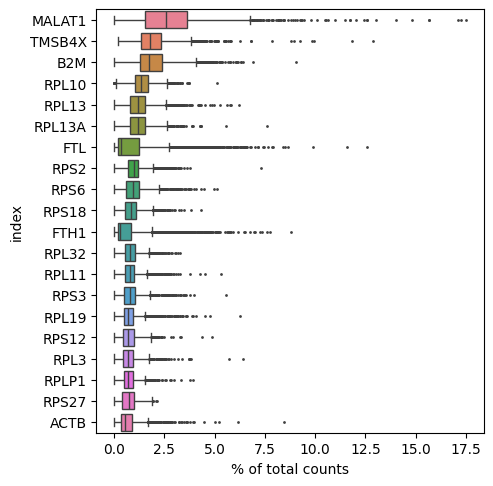

In [6]:
sc.pl.highest_expr_genes(adata, n_top=20)
# this plot shows the top 20 most highly expressed genes in the dataset. Each bar represents a gene, and the height of the bar indicates the level of expression of that gene across all cells in the dataset. The x-axis lists the gene names, while the y-axis shows the average expression level of each gene. This plot helps to identify which genes are most active in the cells being analyzed, which can provide insights into cellular functions and states.


# Now we start preprocessing?

quality control.

We identify:

damaged cells
low-information cells
noisy cells

## VERY IMPORTANT biological idea -- Not every sequenced cell is useful.

In [7]:
# add mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [8]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [9]:
# inspect metadata and qc metrics 
adata.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
index,,,,
AAACATACAACCAC-1,781,2421.0,73.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,186.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,28.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,46.0,1.743085
AAACCGTGTATGCG-1,522,981.0,12.0,1.223242


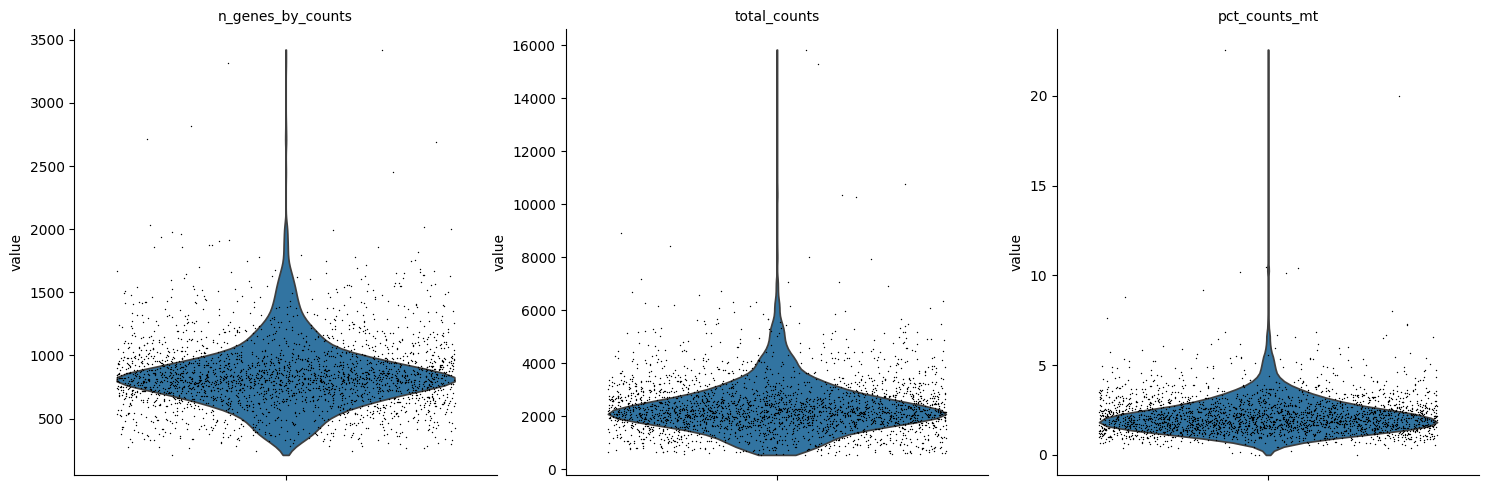

In [10]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

Each black dot =  one cell.

So you are visualizing:

- distribution of cells
- quality of cells
- sequencing behavior

### Typical filtering logic
|Metric	| Bad if |
---n_genes_by_counts	too low
---n_genes_by_counts	too high
--- pct_counts_mt	high
--- total_counts	extreme outlier

high mitochondrial percentage = unhealthy cell.

In [11]:
# remove cells that have too few genes, too many genes, or a high percentage of mitochondrial genes
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

In [12]:
adata.shape

(2638, 32738)

In [13]:
# View dataset shape after filtering
print(adata.shape)


# ---------------- NORMALIZATION ----------------
# Different cells have different sequencing depth.
# We normalize total counts so every cell becomes comparable.

sc.pp.normalize_total(adata, target_sum=1e4)


# ---------------- LOG TRANSFORMATION ----------------
# Gene expression values are highly skewed.
# Log transform compresses very large values and stabilizes variance.
#
# Formula:
# x' = log(1 + x)

sc.pp.log1p(adata)


# ---------------- CHECK NORMALIZED MATRIX ----------------
# View processed expression matrix

adata.X

(2638, 32738)


c:\Users\Ishika Gupta\miniconda3\envs\scRNA\lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2242529 stored elements and shape (2638, 32738)>

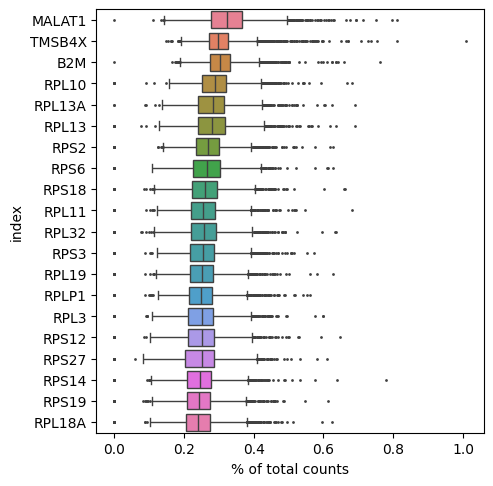

In [14]:
# Visualize highly expressed genes after normalization

sc.pl.highest_expr_genes(adata, n_top=20)

In [15]:
adata.raw = adata

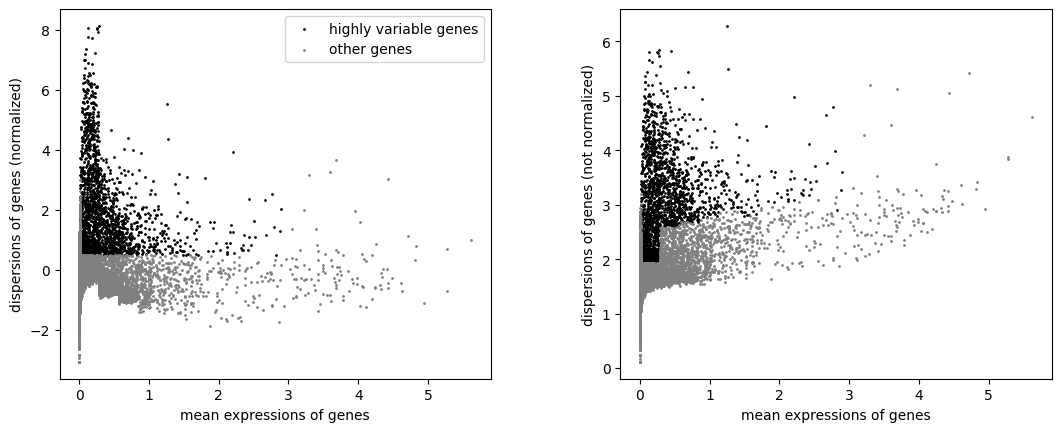

In [16]:
# ---------------- HIGHLY VARIABLE GENES ----------------
# Many genes contain noise or little information.
# We keep only genes showing strong biological variation.

sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)


# Visualize highly variable genes

sc.pl.highly_variable_genes(adata)

In [17]:
# Keep only highly variable genes

adata = adata[:, adata.var.highly_variable]

print(adata.shape)

(2638, 2013)


In [18]:
# ---------------- SCALING ----------------
# Standardize gene expression values.
# This helps PCA and downstream ML methods.

sc.pp.scale(adata, max_value=10)

c:\Users\Ishika Gupta\miniconda3\envs\scRNA\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Ishika Gupta\miniconda3\envs\scRNA\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [19]:
# ---------------- NEIGHBOR GRAPH ----------------
# Identify similar cells in lower-dimensional space.

# sc.pp.neighbors(adata)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30) # more cluster with more neighbors and more principal components

c:\Users\Ishika Gupta\miniconda3\envs\scRNA\lib\site-packages\scanpy\neighbors\__init__.py:577: UserWarning: You’re trying to run this on 2013 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
c:\Users\Ishika Gupta\miniconda3\envs\scRNA\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
!pip3 install igraph
!pip3 install leidenalg

In [21]:
# --------------- LEIDEN CLUSTERING ---------------
# Groups cells into clusters based on similarity in the neighbor graph.
# This is the most important step before any visualization.
# Resolution controls granularity: higher resolution = more clusters.


sc.tl.leiden(adata, resolution=0.5)

print("Number of clusters found:", adata.obs['leiden'].nunique())
print("Cells per cluster:")
print(adata.obs['leiden'].value_counts().sort_index())

C:\Users\Ishika Gupta\AppData\Local\Temp\ipykernel_18076\4010246423.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


Number of clusters found: 6
Cells per cluster:
leiden
0    1183
1     639
2     427
3     340
4      36
5      13
Name: count, dtype: int64


## Leiden clustering uses:

nearest-neighbor graph
high-dimensional PCA space

NOT directly the 2D UMAP coordinates.

So:

clustering is usually more reliable than visual appearance.

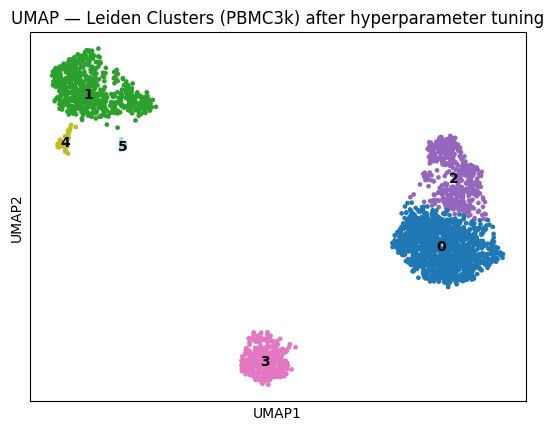

In [22]:
# ---------------- UMAP ----------------
# Visualize cells in 2D space.
# Similar cells cluster together.

sc.tl.umap(adata)

# UMAP colored by cluster — now you can see distinct populations
sc.pl.umap(
    adata,
    color='leiden',
    legend_loc='on data',          # cluster numbers shown on the plot
    legend_fontsize=10,
    title='UMAP — Leiden Clusters (PBMC3k) after hyperparameter tuning',
    frameon=True,
    palette='tab20',               # distinct colors for each cluster
    save=False
)

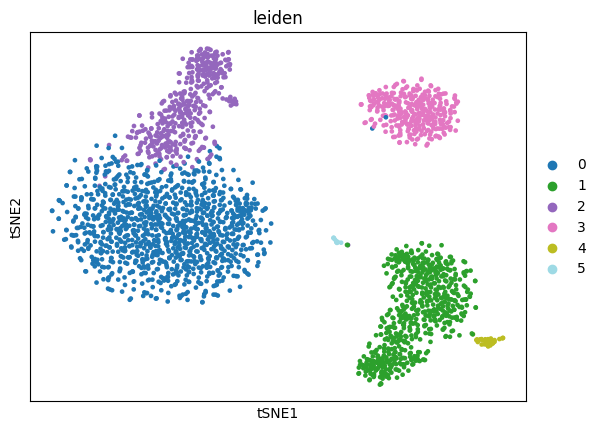

In [23]:
sc.tl.tsne(adata)

sc.pl.tsne(adata, color='leiden')

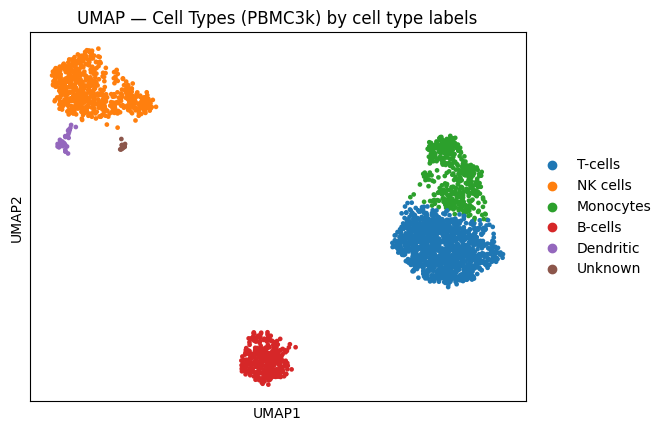

In [24]:
cell_types = {
    '0': 'T-cells',
    '1': 'NK cells',
    '2': 'Monocytes',
    '3': 'B-cells',
    '4': 'Dendritic',
    '5': 'Unknown'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_types)

sc.pl.umap(
    adata,
    color='cell_type',
    title='UMAP — Cell Types (PBMC3k) by cell type labels',
    legend_loc='right margin'
)

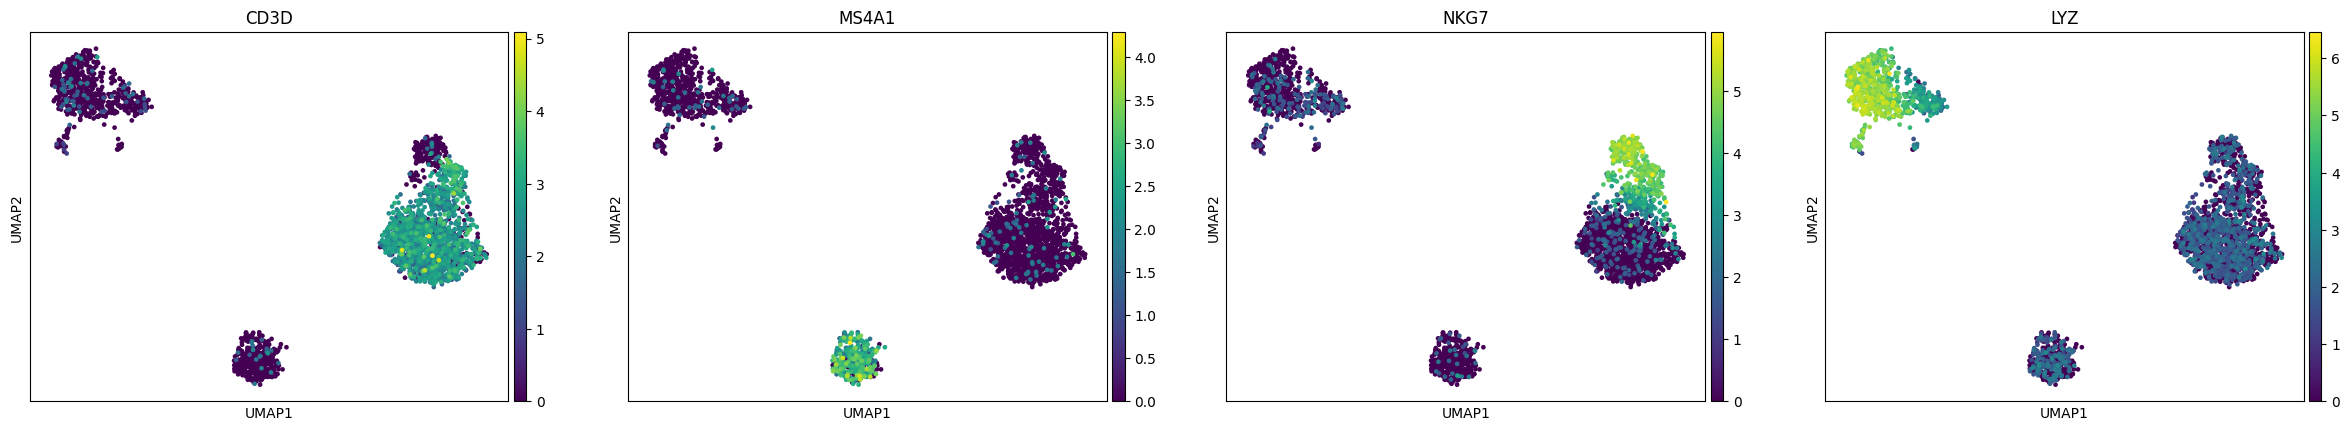

In [25]:
sc.pl.umap(
    adata,
    color=['CD3D', 'MS4A1', 'NKG7', 'LYZ'],
    use_raw=True
)

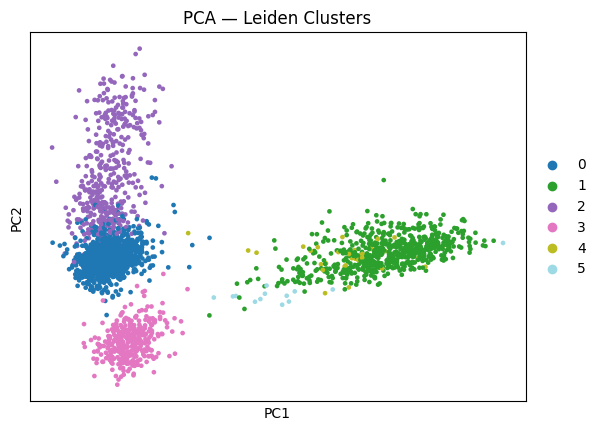

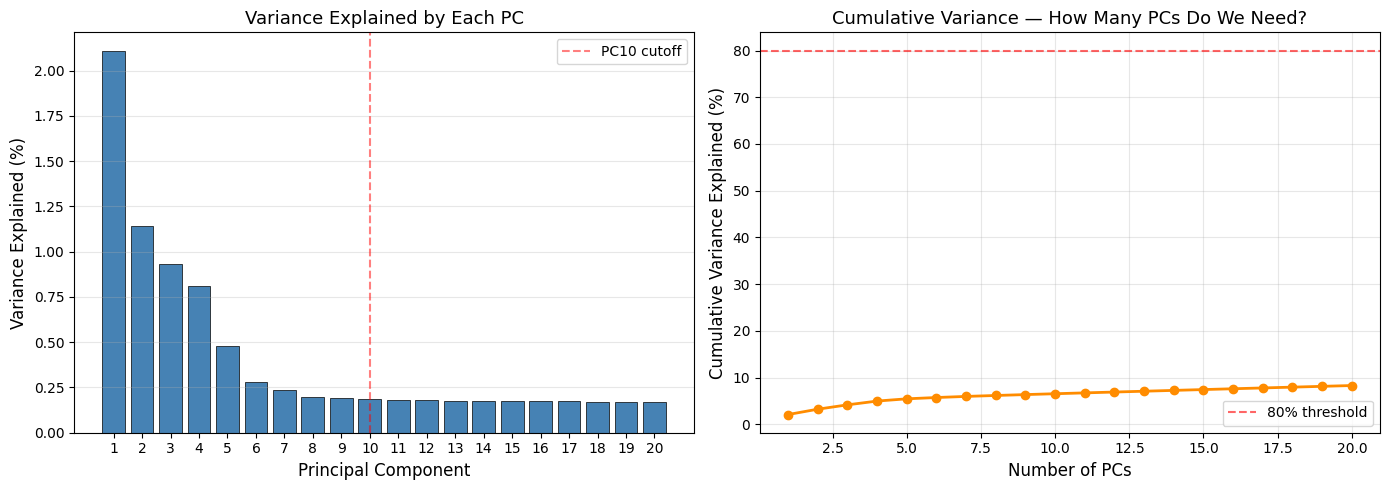


PC1 explains: 2.1% of variance
First 5 PCs explain: 5.5% of variance
First 10 PCs explain: 6.6% of variance


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- PCA with proper axis labels ---
sc.pl.pca(
    adata,
    color='leiden',
    title='PCA — Leiden Clusters',
    legend_loc='right margin',
    frameon=True,
    palette='tab20',
    components='1,2',          # explicitly PC1 vs PC2
)

# --- Variance explained: FIXED version ---
# Extract variance ratio directly from adata
variance_ratio = adata.uns['pca']['variance_ratio']
cumulative_variance = np.cumsum(variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual variance per PC
axes[0].bar(range(1, len(variance_ratio[:20]) + 1),
            variance_ratio[:20] * 100,
            color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('Variance Explained by Each PC', fontsize=13)
axes[0].set_xticks(range(1, 21))
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.5, label='PC10 cutoff')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative variance — tells you when you've captured "enough"
axes[1].plot(range(1, len(cumulative_variance[:20]) + 1),
             cumulative_variance[:20] * 100,
             marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.6, label='80% threshold')
axes[1].set_xlabel('Number of PCs', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
axes[1].set_title('Cumulative Variance — How Many PCs Do We Need?', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPC1 explains: {variance_ratio[0]*100:.1f}% of variance")
print(f"First 5 PCs explain: {cumulative_variance[4]*100:.1f}% of variance")
print(f"First 10 PCs explain: {cumulative_variance[9]*100:.1f}% of variance")

UMAP: 6 clusters (0-5), good separation — this is actually excellent
PCA: Good separation visible
- Cluster 0: LTB, L32, CD2 → T cells
- Cluster 1: CST3, TYROBP → Monocytes
- Cluster 2: NKG7, GZMA, CTSW → NK/CD8 T cells
- Cluster 3: CD79A, HLA-DPB1, HLA-DRB1 → B cells
- Cluster 4: CST3, HLA-DPA1, HLA-DPB1 → Dendritic cells
- Cluster 5: FF4, PPBP, GNG11 → Platelets/Megakaryocytes

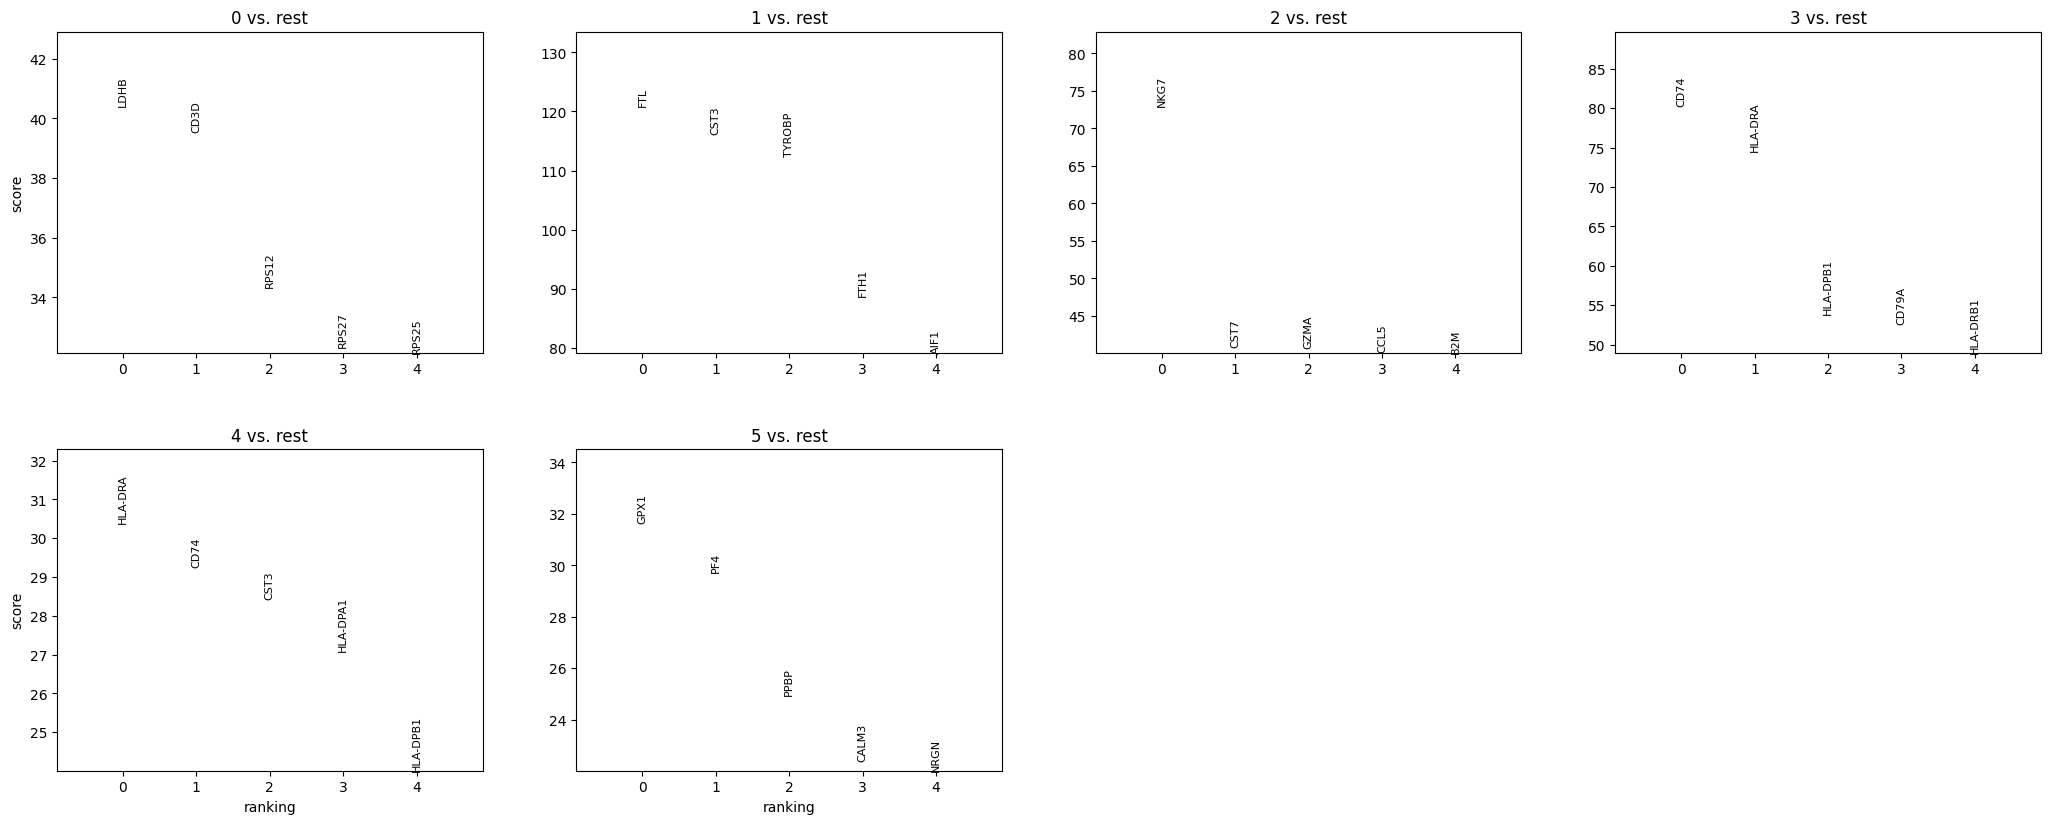

In [27]:
# --------------- DIFFERENTIAL EXPRESSION ---------------
# For each cluster, find genes that are uniquely high in that cluster.
# These marker genes are what biologists use to name cell types.
# Method 't-test' is fast and good for PBMC data.

sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Show top 5 marker genes for each cluster
sc.pl.rank_genes_groups(
    adata,
    n_genes=5,
    sharey=False,
    title='Top Marker Genes per Cluster'
)

In [28]:
import pandas as pd

# Extract top 5 marker genes per cluster into a clean table
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names   # cluster names

marker_table = pd.DataFrame({
    f'Cluster {g}': result['names'][g][:5]
    for g in groups
})

print("=" * 60)
print("TOP 5 MARKER GENES PER CLUSTER")
print("=" * 60)
print(marker_table.to_string(index=True))
print()

# Also show the scores (higher = more specific to that cluster)
score_table = pd.DataFrame({
    f'Cluster {g} (score)': [f"{s:.1f}" for s in result['scores'][g][:5]]
    for g in groups
})
print("SCORES (higher = more specifically expressed in that cluster):")
print(score_table.to_string(index=True))

TOP 5 MARKER GENES PER CLUSTER
  Cluster 0 Cluster 1 Cluster 2 Cluster 3 Cluster 4 Cluster 5
0      LDHB       FTL      NKG7      CD74   HLA-DRA      GPX1
1      CD3D      CST3      CST7   HLA-DRA      CD74       PF4
2     RPS12    TYROBP      GZMA  HLA-DPB1      CST3      PPBP
3     RPS27      FTH1      CCL5     CD79A  HLA-DPA1     CALM3
4     RPS25      AIF1       B2M  HLA-DRB1  HLA-DPB1      NRGN

SCORES (higher = more specifically expressed in that cluster):
  Cluster 0 (score) Cluster 1 (score) Cluster 2 (score) Cluster 3 (score) Cluster 4 (score) Cluster 5 (score)
0              40.4             121.0              73.0              80.3              30.4              31.6
1              39.5             116.2              40.8              74.5              29.2              29.7
2              34.3             112.5              40.6              53.8              28.4              25.0
3              32.3              88.8              40.1              52.5              27.1  

Markers found in dataset: ['NKG7', 'GNLY', 'MS4A1', 'CD79A', 'CST3', 'PPBP', 'LTB', 'GZMA']


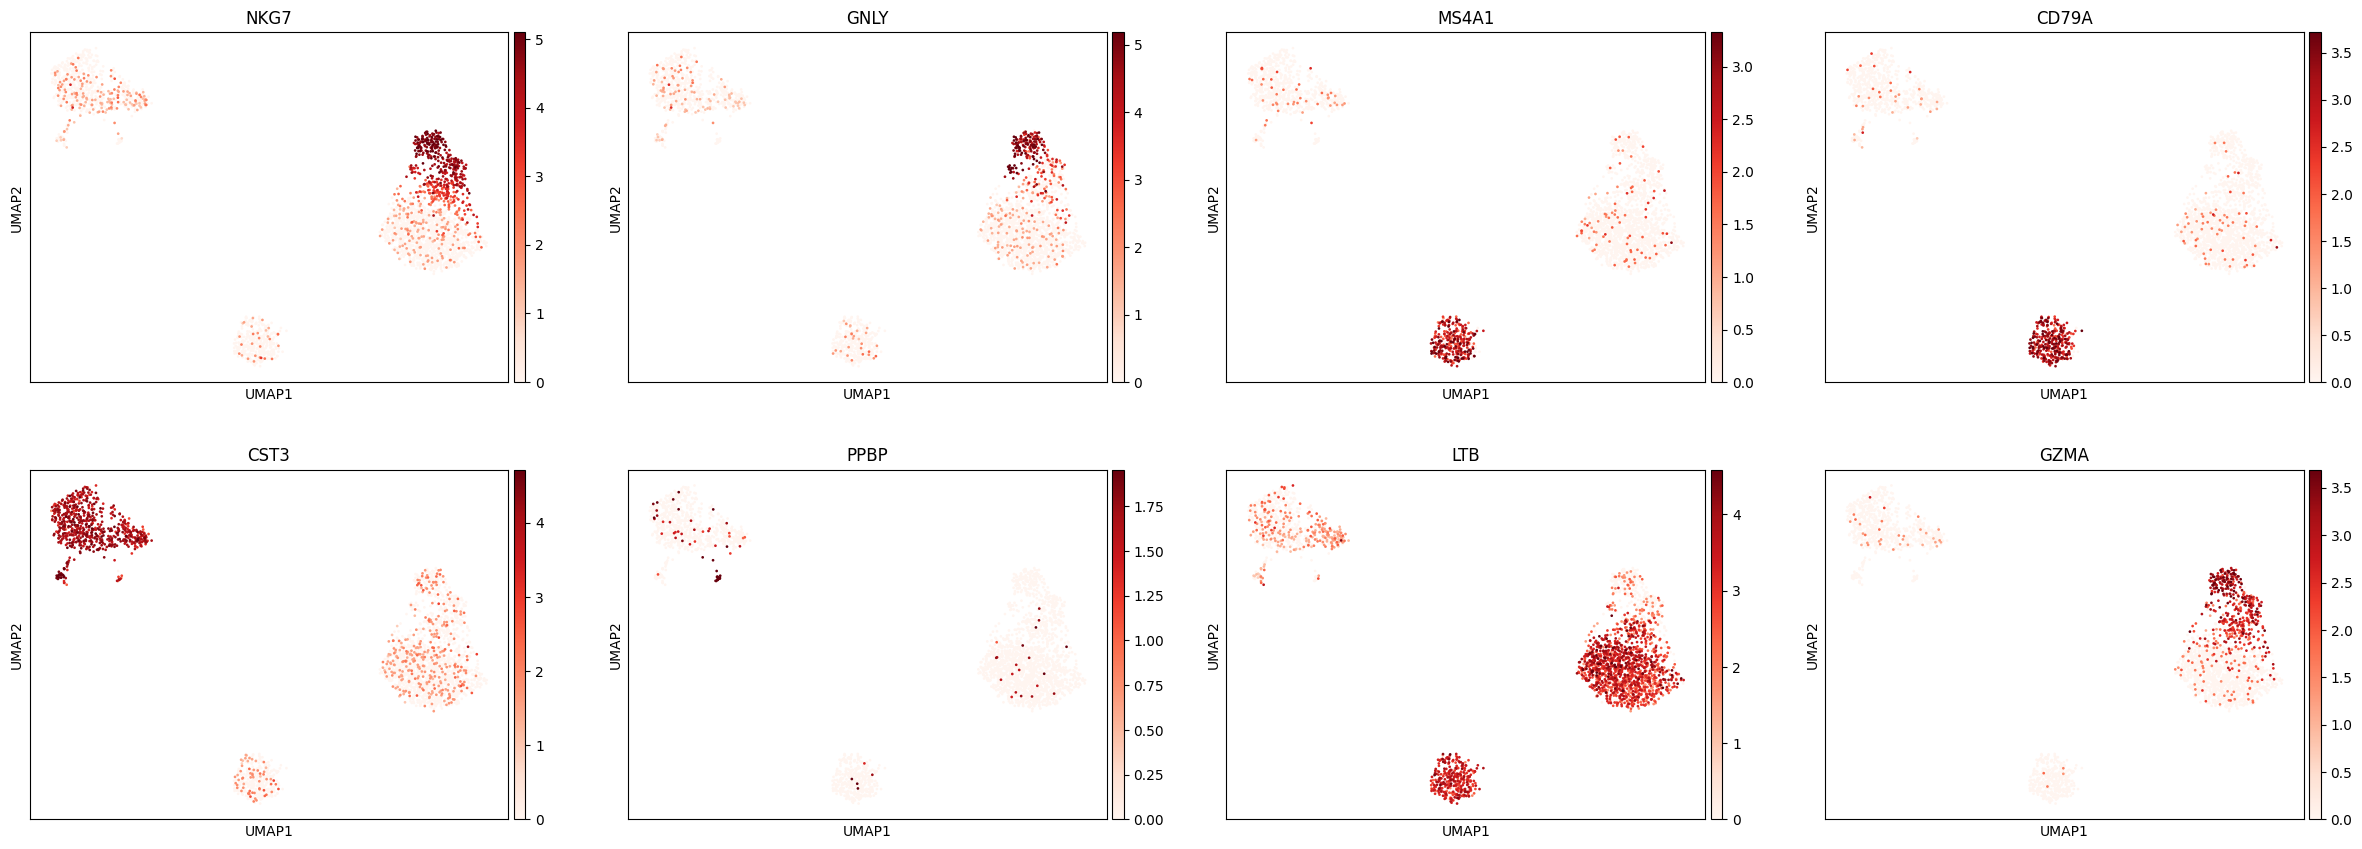

In [29]:
# Known PBMC markers — based on YOUR cluster results above
# Cluster 0 → T cells: LTB, IL7R, CD3D
# Cluster 1 → Monocytes: CST3, LYZ
# Cluster 2 → NK/CD8: NKG7, GNLY, GZMA
# Cluster 3 → B cells: CD79A, MS4A1
# Cluster 4 → Dendritic: CST3, HLA-DPA1
# Cluster 5 → Platelets: PPBP

known_markers = ['CD3D', 'IL7R', 'CD8A', 'NKG7', 'GNLY',
                 'MS4A1', 'CD79A', 'LYZ', 'CST3', 'PPBP',
                 'LTB', 'GZMA']

# Keep only markers present in the dataset
available = [g for g in known_markers if g in adata.var_names]
print(f"Markers found in dataset: {available}")

sc.pl.umap(
    adata,
    color=available,
    ncols=4,
    frameon=True,              # show axis frame
    cmap='Reds',
    vmax='p99',
    size=15,
    title=[g for g in available]
)

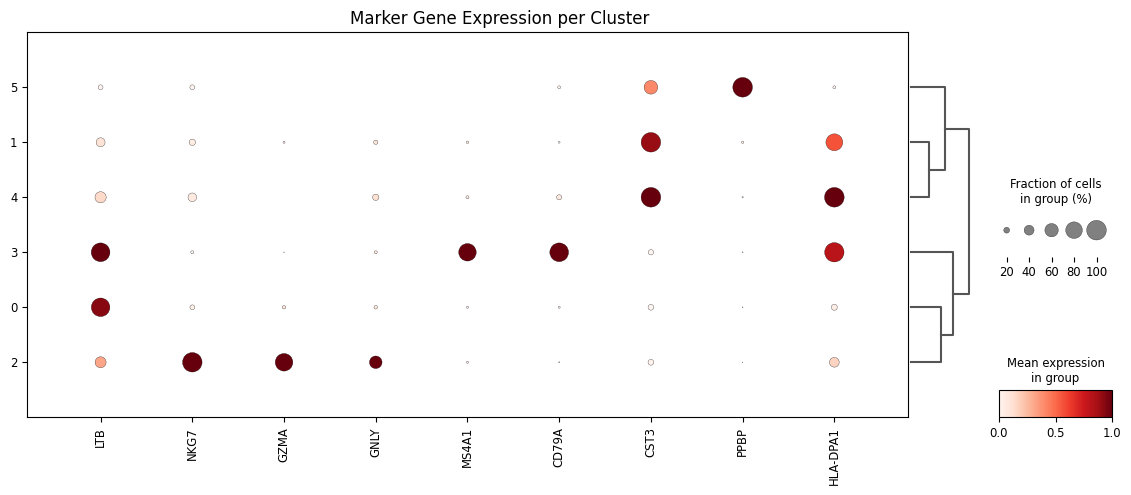

In [30]:
# Dotplot explanation:
# - Each ROW = one Leiden cluster
# - Each COLUMN = one marker gene
# - DOT SIZE = % of cells in that cluster expressing the gene
# - DOT COLOR = average expression level (darker = higher)
# This tells you which cluster is which cell type.

available_for_dot = [g for g in 
    ['LTB', 'IL7R', 'CD3D', 'CD8A', 'NKG7', 'GZMA', 'GNLY',
     'MS4A1', 'CD79A', 'LYZ', 'CST3', 'PPBP', 'HLA-DPA1']
    if g in adata.var_names]

sc.pl.dotplot(
    adata,
    var_names=available_for_dot,
    groupby='leiden',
    dendrogram=True,
    title='Marker Gene Expression per Cluster',
    figsize=(14, 5),
    standard_scale='var',      # normalize each gene 0-1 so colors are comparable
)

In [31]:
# Based on YOUR marker gene results from Block 5:
# Cluster 0: LTB, L32, CD2        → T cells (likely CD4+)
# Cluster 1: CST3, TYROBP         → Monocytes (CD14+)
# Cluster 2: NKG7, GZMA, CTSW    → NK / CD8+ T cells
# Cluster 3: CD79A, HLA-DPB1     → B cells
# Cluster 4: CST3, HLA-DPA1      → Dendritic cells
# Cluster 5: PPBP, GNG11          → Platelets

# IMPORTANT: After running Block 8 dotplot, adjust this mapping
# if the gene patterns suggest something different.

cell_type_map = {
    '0': 'CD4+ T cells',
    '1': 'CD14+ Monocytes',
    '2': 'NK / CD8+ T cells',
    '3': 'B cells',
    '4': 'Dendritic cells',
    '5': 'Platelets',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)
adata.obs['cell_type'] = (
    adata.obs['cell_type']
    .cat.add_categories(['Unknown'])
    .fillna('Unknown')
)

print("Cell type distribution:")
print(adata.obs['cell_type'].value_counts())

Cell type distribution:
cell_type
CD4+ T cells         1183
CD14+ Monocytes       639
NK / CD8+ T cells     427
B cells               340
Dendritic cells        36
Platelets              13
Unknown                 0
Name: count, dtype: int64


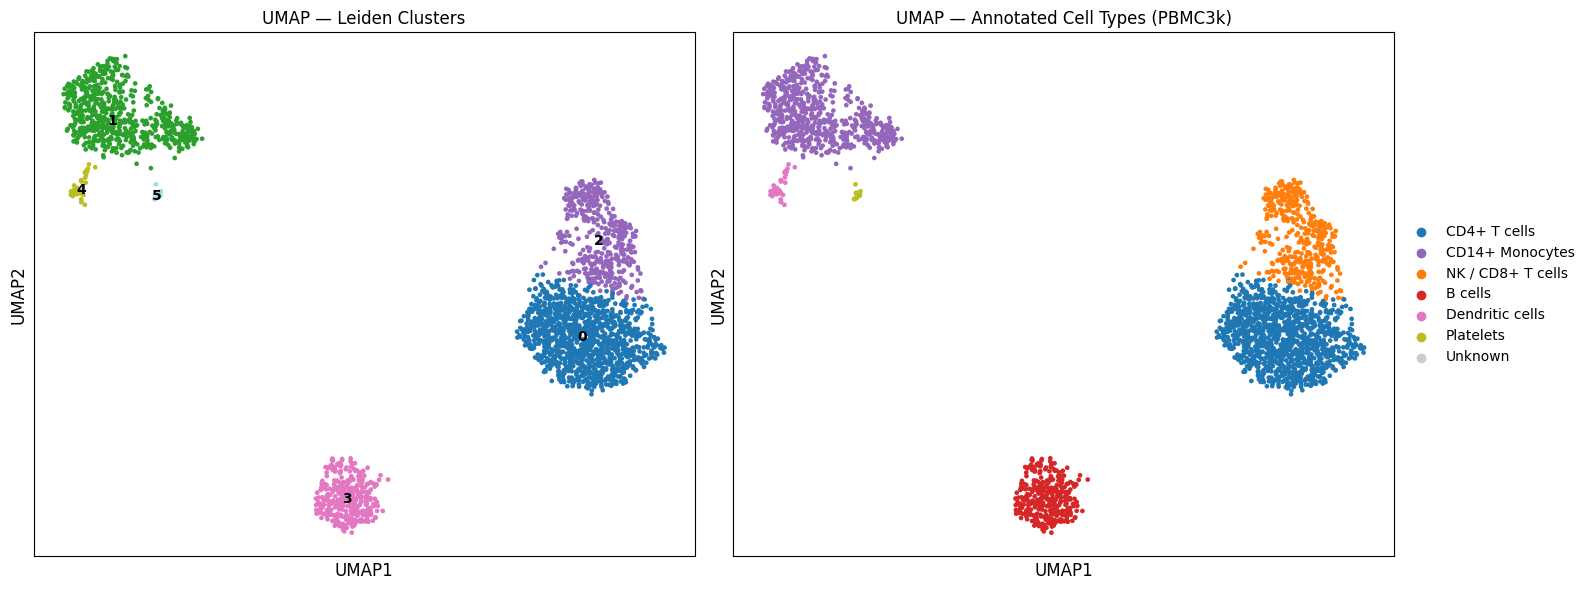

In [32]:
cell_colors = {
    'CD4+ T cells':       '#1f77b4',   # blue
    'NK / CD8+ T cells':  '#ff7f0e',   # orange
    'CD14+ Monocytes':    '#9467bd',   # purple
    'B cells':            '#d62728',   # red
    'Dendritic cells':    '#e377c2',   # pink
    'Platelets':          '#bcbd22',   # yellow-green
    'Unknown':            '#cccccc',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by Leiden cluster number
sc.pl.umap(adata, color='leiden',
           legend_loc='on data', legend_fontsize=10,
           title='UMAP — Leiden Clusters',
           frameon=True, palette='tab20',
           ax=axes[0], show=False)
axes[0].set_xlabel('UMAP1', fontsize=12)
axes[0].set_ylabel('UMAP2', fontsize=12)

# Right: colored by annotated cell type
sc.pl.umap(adata, color='cell_type',
           legend_loc='right margin', legend_fontsize=10,
           title='UMAP — Annotated Cell Types (PBMC3k)',
           frameon=True, palette=cell_colors,
           ax=axes[1], show=False)
axes[1].set_xlabel('UMAP1', fontsize=12)
axes[1].set_ylabel('UMAP2', fontsize=12)

plt.tight_layout()
plt.show()

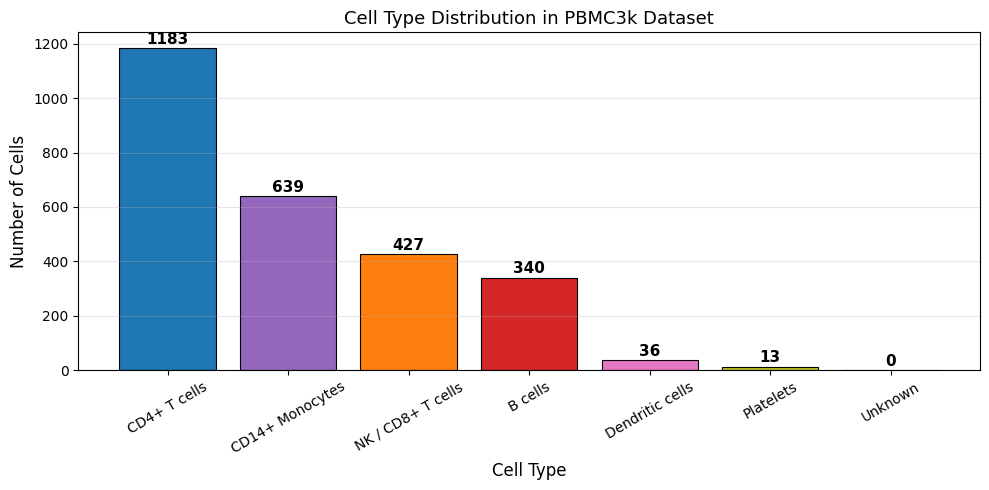


Total cells: 2638
Total genes (HVG): 2013


In [33]:
# Shows how many cells of each type you have
# Useful context for when you build your Transformer (class balance matters)

cell_counts = adata.obs['cell_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cell_counts.index, cell_counts.values,
              color=[cell_colors.get(c, '#999999') for c in cell_counts.index],
              edgecolor='black', linewidth=0.8)

# Add count labels on top of bars
for bar, count in zip(bars, cell_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Cell Type', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)
ax.set_title('Cell Type Distribution in PBMC3k Dataset', fontsize=13)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal cells: {len(adata)}")
print(f"Total genes (HVG): {adata.shape[1]}")

In [34]:
adata.write_h5ad('pbmc3k_annotated.h5ad')

print("Saved successfully!")
print(f"Shape: {adata.shape}")
print(f"Embeddings stored: {list(adata.obsm.keys())}")
print(f"Cluster info: {adata.obs['leiden'].nunique()} Leiden clusters")
print(f"Cell types assigned: {adata.obs['cell_type'].nunique()} types")
print("\nStage 1 complete. Ready to build the Transformer.")

Saved successfully!
Shape: (2638, 2013)
Embeddings stored: ['X_pca', 'X_umap', 'X_tsne']
Cluster info: 6 Leiden clusters
Cell types assigned: 6 types

Stage 1 complete. Ready to build the Transformer.


# Stage 2: model building

In [35]:
# Run this first to make sure all libraries are available
import subprocess
subprocess.run(['pip', 'install', 'torch', 'scikit-learn', 
                'matplotlib', 'seaborn', 'numpy', 'pandas'], 
               capture_output=True)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.12.0+cu126
GPU available: True
GPU name: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [36]:

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
    
    # Quick real computation test
    x = torch.randn(3000, 3000).cuda()
    y = torch.randn(3000, 3000).cuda()
    z = torch.mm(x, y)
    print("GPU compute test: PASSED")
    print("Device:", z.device)
    
    device = torch.device('cuda')
    print("\nGPU is READY. Proceed to Stage 2.")
else:
    print("Still CPU — something went wrong with installation.")

GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM: 4.3 GB
GPU compute test: PASSED
Device: cuda:0

GPU is READY. Proceed to Stage 2.


In [37]:
# Load the file you saved at end of Stage 1
adata = sc.read_h5ad('pbmc3k_annotated.h5ad')

print("Loaded successfully!")
print(f"Shape: {adata.shape}")
print(f"Cell types: {adata.obs['cell_type'].value_counts().to_dict()}")

# Check what we have stored
print(f"\nEmbeddings available: {list(adata.obsm.keys())}")
print(f"Obs columns: {list(adata.obs.columns)}")

Loaded successfully!
Shape: (2638, 2013)
Cell types: {'CD4+ T cells': 1183, 'CD14+ Monocytes': 639, 'NK / CD8+ T cells': 427, 'B cells': 340, 'Dendritic cells': 36, 'Platelets': 13, 'Unknown': 0}

Embeddings available: ['X_pca', 'X_tsne', 'X_umap']
Obs columns: ['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type']


In [38]:
# Extract the gene expression matrix (2638 cells × 2013 genes)
# We use the SCALED matrix (stored in adata.X after scaling)
# This is what the Transformer will receive as input

X_raw = adata.X  # scaled expression matrix

# Convert sparse matrix to dense numpy array if needed
if hasattr(X_raw, 'toarray'):
    X = X_raw.toarray().astype(np.float32)
else:
    X = np.array(X_raw, dtype=np.float32)

# Get cell type labels
labels_raw = adata.obs['cell_type'].values

# Encode string labels to integers (required for PyTorch)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_raw)

# Show the encoding mapping (important to remember)
print("Label encoding:")
for i, name in enumerate(label_encoder.classes_):
    count = np.sum(y == i)
    print(f"  {i} → {name}  ({count} cells)")

print(f"\nX shape: {X.shape}  (cells × genes)")
print(f"y shape: {y.shape}  (integer labels)")
print(f"Value range: min={X.min():.2f}, max={X.max():.2f}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Label encoding:
  0 → B cells  (340 cells)
  1 → CD14+ Monocytes  (639 cells)
  2 → CD4+ T cells  (1183 cells)
  3 → Dendritic cells  (36 cells)
  4 → NK / CD8+ T cells  (427 cells)
  5 → Platelets  (13 cells)

X shape: (2638, 2013)  (cells × genes)
y shape: (2638,)  (integer labels)
Value range: min=-1.95, max=10.00
Number of classes: 6


In [39]:
# Stratified split — ensures all 6 cell types appear in both train and test
# Even small classes (Dendritic=36, Platelets=13) get represented
# test_size=0.2 means 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # critical for imbalanced data
)

print(f"Training set:  {X_train.shape[0]} cells")
print(f"Test set:      {X_test.shape[0]} cells")
print(f"Gene features: {X_train.shape[1]}")
print()

# Check class distribution in train set
print("Train set class distribution:")
for i, name in enumerate(label_encoder.classes_):
    count = np.sum(y_train == i)
    print(f"  {name}: {count} cells")

Training set:  2110 cells
Test set:      528 cells
Gene features: 2013

Train set class distribution:
  B cells: 272 cells
  CD14+ Monocytes: 511 cells
  CD4+ T cells: 946 cells
  Dendritic cells: 29 cells
  NK / CD8+ T cells: 342 cells
  Platelets: 10 cells


In [40]:
# ============================================================
# BASELINE MODEL: Random Forest
# This is what we compare our Transformer against.
# A recruiter will ask: "What did RF get?" — you need this number.
# ============================================================

print("Training Random Forest baseline...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,          # use all CPU cores
    class_weight='balanced'   # handles class imbalance
)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Test Accuracy: {rf_accuracy*100:.2f}%")
print()
print("Per-class performance:")
print(classification_report(
    y_test, y_pred_rf,
    target_names=label_encoder.classes_,
    digits=3
))

Training Random Forest baseline...

Random Forest Test Accuracy: 95.83%

Per-class performance:
                   precision    recall  f1-score   support

          B cells      0.985     0.985     0.985        68
  CD14+ Monocytes      0.962     1.000     0.981       128
     CD4+ T cells      0.955     0.975     0.965       237
  Dendritic cells      1.000     0.286     0.444         7
NK / CD8+ T cells      0.938     0.882     0.909        85
        Platelets      1.000     1.000     1.000         3

         accuracy                          0.958       528
        macro avg      0.973     0.855     0.881       528
     weighted avg      0.959     0.958     0.956       528



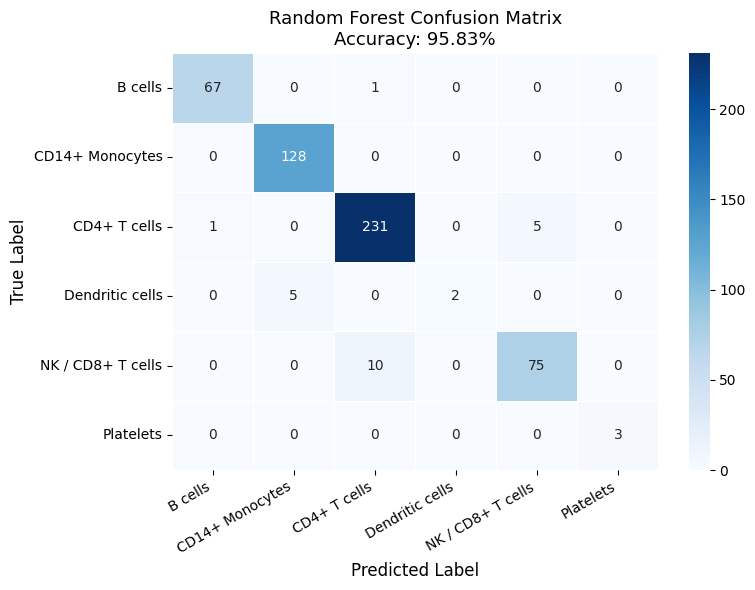


Baseline RF accuracy saved: 95.83%
Now building Transformer...


In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True, fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap='Blues', ax=ax,
    linewidths=0.5
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Random Forest Confusion Matrix\nAccuracy: {rf_accuracy*100:.2f}%', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save RF accuracy for final comparison
print(f"\nBaseline RF accuracy saved: {rf_accuracy*100:.2f}%")
print("Now building Transformer...")

In [42]:
# ============================================================
# PYTORCH DATASET
# Wraps numpy arrays into a format PyTorch DataLoader can use.
# Each item = (gene_expression_vector, cell_type_label)
# ============================================================

class SingleCellDataset(Dataset):
    def __init__(self, X, y):
        # Convert to PyTorch tensors
        self.X = torch.FloatTensor(X)   # gene expression: shape (n_cells, 2013)
        self.y = torch.LongTensor(y)    # cell type label: shape (n_cells,)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = SingleCellDataset(X_train, y_train)
test_dataset  = SingleCellDataset(X_test,  y_test)

print(f"Train dataset: {len(train_dataset)} cells")
print(f"Test dataset:  {len(test_dataset)} cells")
print(f"Input shape per cell: {train_dataset.X.shape[1]} genes")
print(f"Sample — X shape: {train_dataset[0][0].shape}, label: {train_dataset[0][1]}")

Train dataset: 2110 cells
Test dataset:  528 cells
Input shape per cell: 2013 genes
Sample — X shape: torch.Size([2013]), label: 1


In [44]:
# ============================================================
# WEIGHTED SAMPLER
# Problem: Platelets=13, Dendritic=36 are tiny classes.
# Without this, the model ignores them and still gets high accuracy
# by predicting only T cells (the majority class).
# Solution: oversample rare classes during training.
# ============================================================

# Calculate weight for each sample: rarer class = higher weight
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]

print("Class counts in training set:", class_counts)
print("Class weights (inverse frequency):", [f"{w:.4f}" for w in class_weights])

from torch.utils.data import WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders — batches of 64 cells at a time
# shuffle=False when using sampler (sampler handles shuffling)
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"\nBatch size: 64")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Class counts in training set: [272 511 946  29 342  10]
Class weights (inverse frequency): ['0.0037', '0.0020', '0.0011', '0.0345', '0.0029', '0.1000']

Batch size: 64
Training batches per epoch: 33
Test batches: 9


In [45]:
# ============================================================
# TRANSFORMER ENCODER FOR SINGLE-CELL DATA
#
# Design thinking:
# - Input: 2013 genes per cell (treat each gene as a token)
# - We project genes into an embedding space (d_model=128)
# - Transformer Encoder layers learn gene-gene relationships
#   via self-attention (this is what RF cannot do)
# - CLS token aggregates whole-cell representation
# - Final classifier head predicts cell type
#
# Why this architecture is justified over RF:
# - Self-attention captures GENE-GENE dependencies
# - Attention weights are interpretable (which genes matter)
# - Generalizes better across datasets (batch robustness)
# ============================================================

class GeneEmbedding(nn.Module):
    """Projects each gene's expression value into a dense embedding."""
    def __init__(self, n_genes, d_model):
        super().__init__()
        # Each gene gets its own learnable embedding vector
        # scaled by its expression value
        self.gene_embed = nn.Embedding(n_genes, d_model)
        self.value_proj  = nn.Linear(1, d_model)
        self.norm = nn.LayerNorm(d_model)
        
    def forward(self, x):
        # x shape: (batch, n_genes)
        batch_size, n_genes = x.shape
        
        # Gene identity embeddings
        gene_ids = torch.arange(n_genes, device=x.device)         # (n_genes,)
        gene_emb = self.gene_embed(gene_ids)                       # (n_genes, d_model)
        gene_emb = gene_emb.unsqueeze(0).expand(batch_size, -1, -1) # (batch, n_genes, d_model)
        
        # Expression value embeddings
        val_emb = self.value_proj(x.unsqueeze(-1))                 # (batch, n_genes, d_model)
        
        # Combine: gene identity + expression level
        combined = self.norm(gene_emb + val_emb)                   # (batch, n_genes, d_model)
        return combined


class SingleCellTransformer(nn.Module):
    def __init__(self, n_genes, n_classes, d_model=128, n_heads=4,
                 n_layers=2, d_ff=256, dropout=0.1):
        super().__init__()
        
        self.d_model  = d_model
        self.n_genes  = n_genes
        
        # 1. Gene embedding layer
        self.gene_embedding = GeneEmbedding(n_genes, d_model)
        
        # 2. CLS token — a learnable "summary" token
        #    After attention, this token summarizes the whole cell
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # 3. Transformer Encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,    # (batch, seq, features)
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
            enable_nested_tensor=False
        )
        
        # 4. Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
    
    def forward(self, x, return_attention=False):
        batch_size = x.shape[0]
        
        # Gene embeddings: (batch, n_genes, d_model)
        gene_emb = self.gene_embedding(x)
        
        # Prepend CLS token: (batch, 1+n_genes, d_model)
        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls, gene_emb], dim=1)
        
        # Transformer: learns gene-gene relationships
        # Each gene token attends to all other genes
        out = self.transformer(tokens)        # (batch, 1+n_genes, d_model)
        
        # CLS token output = cell-level representation
        cls_out = out[:, 0, :]               # (batch, d_model)
        
        # Classify
        logits = self.classifier(cls_out)    # (batch, n_classes)
        return logits
    
    def get_attention_weights(self, x):
        """Extract attention weights for biological interpretation."""
        # Used in Stage 3 to visualize which genes the model focuses on
        self.eval()
        with torch.no_grad():
            gene_emb = self.gene_embedding(x)
            cls = self.cls_token.expand(x.shape[0], -1, -1)
            tokens = torch.cat([cls, gene_emb], dim=1)
            
            # Get attention from first encoder layer
            attn_layer = self.transformer.layers[0].self_attn
            attn_out, attn_weights = attn_layer(
                tokens, tokens, tokens,
                need_weights=True,
                average_attn_weights=True
            )
        return attn_weights  # (batch, seq_len, seq_len)


# Instantiate model
N_GENES   = X_train.shape[1]   # 2013
N_CLASSES = len(label_encoder.classes_)  # 6

model = SingleCellTransformer(
    n_genes=N_GENES,
    n_classes=N_CLASSES,
    d_model=128,      # embedding dimension (kept small for 4GB VRAM)
    n_heads=4,        # attention heads (d_model must be divisible by n_heads)
    n_layers=2,       # transformer layers (enough for this dataset size)
    d_ff=256,         # feedforward dimension
    dropout=0.1
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Model on device:      {next(model.parameters()).device}")

Model architecture:
SingleCellTransformer(
  (gene_embedding): GeneEmbedding(
    (gene_embed): Embedding(2013, 128)
    (value_proj): Linear(in_features=1, out_features=128, bias=True)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  

In [48]:
# ============================================================
# TRAINING SETUP
# - Loss: CrossEntropy with class weights (handles imbalance)
# - Optimizer: AdamW (better than Adam for Transformers)
# - Scheduler: ReduceLROnPlateau (reduces LR when stuck)
# ============================================================

# Class weights for loss — penalizes wrong predictions on rare classes more
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',       # maximize validation accuracy
    factor=0.5,       # halve LR when stuck
    patience=5
)

N_EPOCHS = 60

print(f"Training for {N_EPOCHS} epochs")
print(f"Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)")
print(f"Loss: CrossEntropyLoss with class weights")
print(f"Scheduler: ReduceLROnPlateau (patience=5)")
print(f"Device: {device}")

Training for 60 epochs
Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)
Loss: CrossEntropyLoss with class weights
Scheduler: ReduceLROnPlateau (patience=5)
Device: cuda


In [49]:
# ============================================================
# TRAINING LOOP
# Tracks: train loss, train accuracy, test accuracy per epoch
# ============================================================

train_losses = []
train_accs   = []
test_accs    = []
best_test_acc = 0.0
best_model_state = None

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8} | {'LR':>8}")
print("-" * 55)

for epoch in range(N_EPOCHS):
    # ---- TRAINING PHASE ----
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        
        # Gradient clipping — stabilizes Transformer training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
    
    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total
    
    # ---- EVALUATION PHASE ----
    model.eval()
    correct_test, total_test = 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            preds  = logits.argmax(dim=1)
            correct_test += (preds == y_batch).sum().item()
            total_test   += len(y_batch)
    
    test_acc = correct_test / total_test
    scheduler.step(test_acc)
    
    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    # Log every 5 epochs
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:>6} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | "
              f"{test_acc*100:>7.2f}% | {current_lr:>8.6f}")

print(f"\nBest test accuracy: {best_test_acc*100:.2f}%")
print(f"Random Forest was:  {rf_accuracy*100:.2f}%")

 Epoch | Train Loss | Train Acc | Test Acc |       LR
-------------------------------------------------------
     1 |     0.9163 |    17.35% |    0.57% | 0.001000
     5 |     0.1347 |    55.50% |   21.97% | 0.001000
    10 |     0.0960 |    63.18% |   35.04% | 0.001000
    15 |     0.0668 |    74.17% |   50.00% | 0.001000
    20 |     0.0200 |    93.08% |   80.87% | 0.001000
    25 |     0.0202 |    95.78% |   87.69% | 0.001000
    30 |     0.0113 |    96.07% |   91.67% | 0.001000
    35 |     0.0096 |    96.02% |   91.29% | 0.000500
    40 |     0.0052 |    97.30% |   92.42% | 0.000500
    45 |     0.0049 |    97.73% |   92.61% | 0.000250
    50 |     0.0052 |    97.77% |   93.75% | 0.000125
    55 |     0.0042 |    98.25% |   93.75% | 0.000063
    60 |     0.0056 |    97.96% |   93.75% | 0.000031

Best test accuracy: 95.27%
Random Forest was:  95.83%


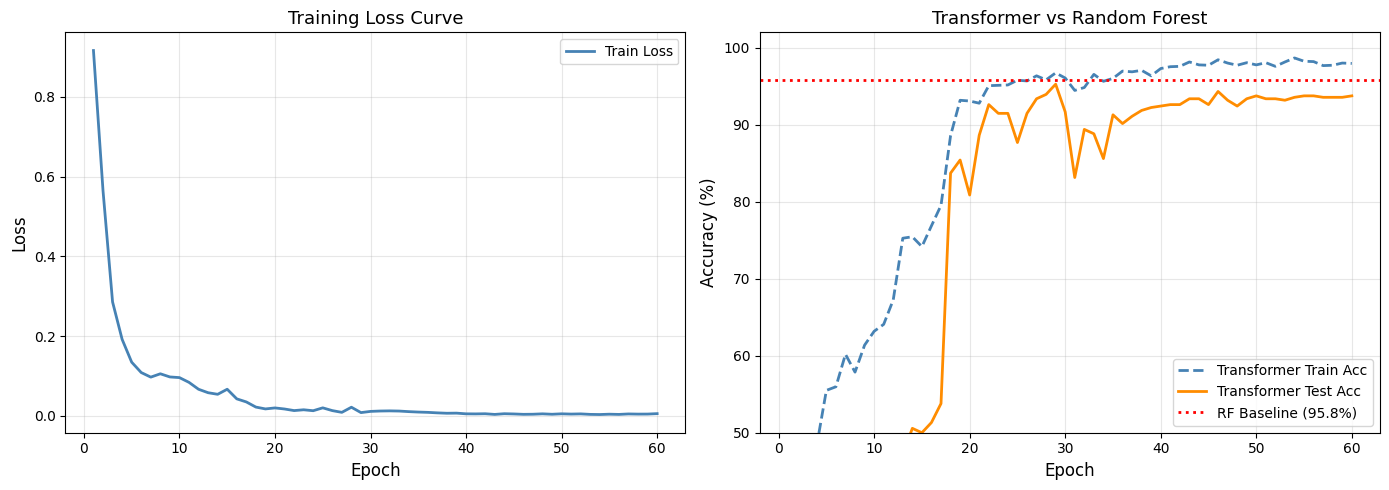


Final comparison:
  Random Forest accuracy:    95.83%
  Transformer best accuracy: 95.27%


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, N_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs_range, train_losses, color='steelblue', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Curve', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve — Transformer vs RF baseline
axes[1].plot(epochs_range, [a*100 for a in train_accs],
             color='steelblue', linewidth=2, label='Transformer Train Acc', linestyle='--')
axes[1].plot(epochs_range, [a*100 for a in test_accs],
             color='darkorange', linewidth=2, label='Transformer Test Acc')
axes[1].axhline(y=rf_accuracy*100, color='red', linestyle=':', linewidth=2,
                label=f'RF Baseline ({rf_accuracy*100:.1f}%)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Transformer vs Random Forest', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([50, 102])

plt.tight_layout()
plt.show()

print(f"\nFinal comparison:")
print(f"  Random Forest accuracy:    {rf_accuracy*100:.2f}%")
print(f"  Transformer best accuracy: {best_test_acc*100:.2f}%")

In [51]:
# Load the best model weights saved during training
model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

transformer_accuracy = accuracy_score(all_labels, all_preds)

print(f"Transformer Final Test Accuracy: {transformer_accuracy*100:.2f}%")
print()
print("Per-class performance (Transformer):")
print(classification_report(
    all_labels, all_preds,
    target_names=label_encoder.classes_,
    digits=3
))

Transformer Final Test Accuracy: 95.27%

Per-class performance (Transformer):
                   precision    recall  f1-score   support

          B cells      0.970     0.941     0.955        68
  CD14+ Monocytes      1.000     0.961     0.980       128
     CD4+ T cells      0.974     0.941     0.957       237
  Dendritic cells      0.636     1.000     0.778         7
NK / CD8+ T cells      0.865     0.976     0.917        85
        Platelets      1.000     1.000     1.000         3

         accuracy                          0.953       528
        macro avg      0.907     0.970     0.931       528
     weighted avg      0.958     0.953     0.954       528



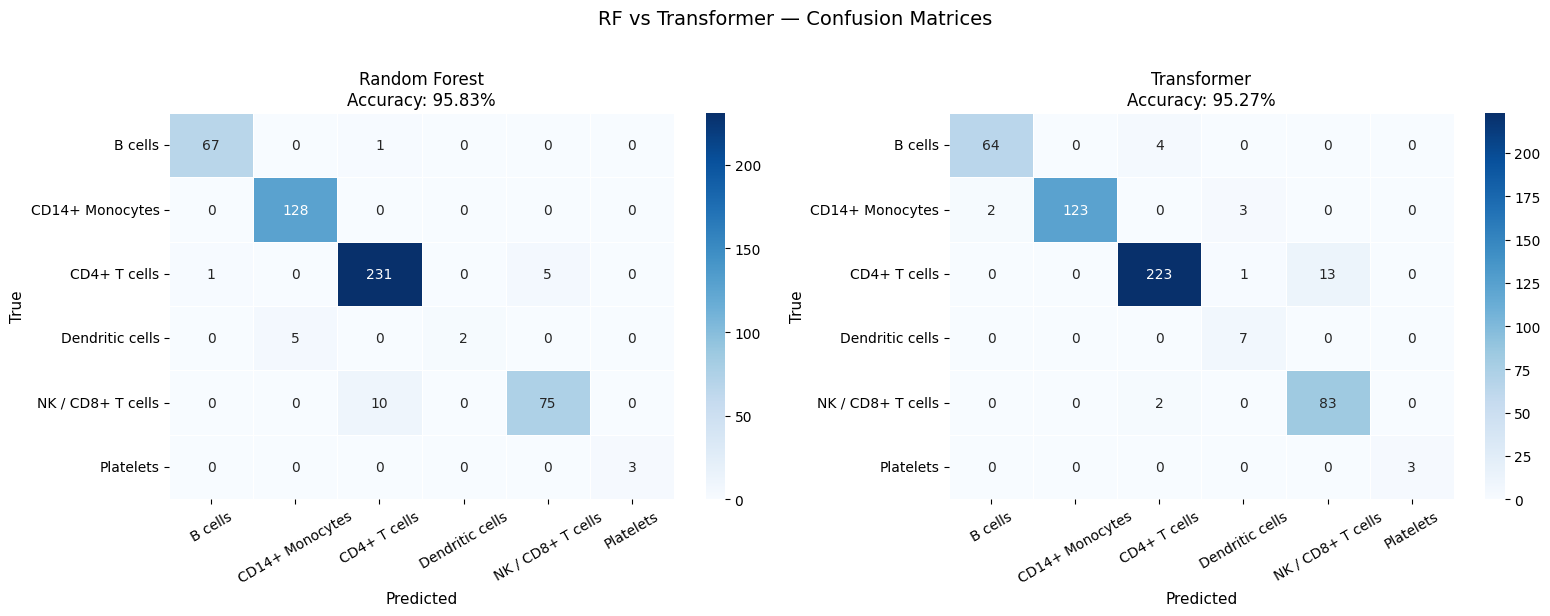

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_transformer = confusion_matrix(all_labels, all_preds)

for ax, cm, title, acc in zip(
    axes,
    [cm_rf, cm_transformer],
    ['Random Forest', 'Transformer'],
    [rf_accuracy, transformer_accuracy]
):
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        cmap='Blues', ax=ax, linewidths=0.5
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontsize=12)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('RF vs Transformer — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# ATTENTION VISUALIZATION
# This is what makes the Transformer scientifically valuable.
# We show WHICH GENES the model attends to for each cell type.
# RF cannot produce this — this is your key differentiator.
# ============================================================

# Known important marker genes for PBMC cell types
marker_genes = ['CD3D', 'CD3E', 'IL7R', 'CD8A', 'NKG7',
                'GZMA', 'MS4A1', 'CD79A', 'LYZ', 'CST3', 'PPBP']

# Get indices of these genes in the HVG list
gene_names   = list(adata.var_names)
marker_idx   = [gene_names.index(g) for g in marker_genes if g in gene_names]
found_markers = [g for g in marker_genes if g in gene_names]

print(f"Marker genes found: {found_markers}")
print(f"Their indices in HVG list: {marker_idx}")

# Get one batch of test cells with labels
model.eval()
X_sample = torch.FloatTensor(X_test[:128]).to(device)
y_sample  = y_test[:128]

# Extract attention weights
attn_weights = model.get_attention_weights(X_sample)
# Shape: (batch, seq_len, seq_len) where seq_len = 1 + n_genes (CLS + genes)
# attn_weights[:, 0, 1:] = attention FROM cls token TO each gene
cls_to_gene_attn = attn_weights[:, 0, 1:].cpu().numpy()  # (batch, n_genes)

print(f"\nAttention weights shape: {cls_to_gene_attn.shape}")
print("(Each row = one cell, each column = one gene's attention score)")

Marker genes found: ['NKG7', 'GZMA', 'MS4A1', 'CD79A', 'CST3', 'PPBP']
Their indices in HVG list: [1900, 550, 1106, 1874, 1732, 497]


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

class_names = label_encoder.classes_

for class_idx, (ax, class_name) in enumerate(zip(axes, class_names)):
    # Get cells of this class in our sample
    cell_mask = (y_sample == class_idx)
    
    if cell_mask.sum() == 0:
        ax.set_title(f'{class_name}\n(no samples in batch)')
        ax.axis('off')
        continue
    
    # Average attention across cells of this type
    avg_attn = cls_to_gene_attn[cell_mask].mean(axis=0)  # (n_genes,)
    
    # Get top 15 attended genes
    top_idx   = np.argsort(avg_attn)[-15:][::-1]
    top_genes = [gene_names[i] for i in top_idx]
    top_vals  = avg_attn[top_idx]
    
    # Color bars: red if it's a known marker gene, blue otherwise
    colors = ['#d62728' if g in found_markers else '#1f77b4' for g in top_genes]
    
    bars = ax.barh(range(len(top_genes)), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top_genes)))
    ax.set_yticklabels(top_genes[::-1], fontsize=9)
    ax.set_xlabel('Attention Score', fontsize=9)
    ax.set_title(f'{class_name}\n(n={cell_mask.sum()} cells)', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='Known marker gene'),
                   Patch(facecolor='#1f77b4', label='Other gene')]
fig.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.suptitle('Genes Attended to by Transformer — Per Cell Type\n'
             '(Red = known biological marker genes)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nKey finding to present:")
print("If red bars (known marker genes) appear highly attended for the correct cell type,")
print("it confirms the Transformer learned biologically meaningful patterns.")

In [ ]:
# Save model
torch.save({
    'model_state_dict': best_model_state,
    'label_encoder_classes': label_encoder.classes_,
    'gene_names': gene_names,
    'n_genes': N_GENES,
    'n_classes': N_CLASSES,
    'best_test_acc': best_test_acc,
    'rf_accuracy': rf_accuracy,
}, 'single_cell_transformer.pt')

# Save results summary
results = {
    'Random Forest': rf_accuracy * 100,
    'Transformer':   best_test_acc * 100,
}
print("=" * 40)
print("FINAL RESULTS SUMMARY")
print("=" * 40)
for model_name, acc in results.items():
    print(f"  {model_name:20s}: {acc:.2f}%")
print()
print("Model saved to: single_cell_transformer.pt")
print("Stage 2 complete.")
print("\nStage 3 (cross-dataset transfer) is the next step.")